# Recommendation System Training (Association Rules)

This notebook trains a **recommendation model** using synthetic transaction data.

### Objectives
- Simulate user purchase behavior using mock data
- Train an association rule model using Apriori
- Generate product recommendations
- Export the trained model for use in Django backend

### Output
- `recommendation.pkl` (trained model)

In [1]:
import json
import pandas as pd
import pickle
from mlxtend.frequent_patterns import apriori, association_rules

##  Load Mock Transaction Data

We use synthetic transaction data where each row represents a customer order.

Example: ["Fresh Tomato", "Cavendish Banana"]

This replaces the need for a live database during model development.


In [2]:
with open("mock_transactions.json", "r") as f:
    transactions = json.load(f)

transactions[:5]

[['Fresh Fuji Apple', 'Cavendish Banana', 'Fresh Tomato'],
 ['Fresh Tomato', 'Organic Carrot'],
 ['Cavendish Banana', 'Fresh Tomato'],
 ['Fresh Fuji Apple', 'Cavendish Banana'],
 ['Valencia Orange', 'Ripe Mango', 'Fresh Strawberry']]

## Data Preprocessing

We convert transactions into a **one-hot encoded format** required by the Apriori algorithm.

Each column = product  
Each row = transaction  
Value = True/False (whether product is present)

In [3]:
def preprocess(transactions):
    all_items = sorted(set(item for t in transactions for item in t))

    encoded = []
    for t in transactions:
        row = {item: (item in t) for item in all_items}
        encoded.append(row)

    return pd.DataFrame(encoded)

df = preprocess(transactions)
df.head()

,Cavendish Banana,Cherry Tomato,Fresh Bell Pepper,Fresh Cucumber,Fresh Fuji Apple,Fresh Guava,Fresh Pomegranate,Fresh Potato,Fresh Strawberry,Fresh Tomato,Green Grapes,Organic Carrot,Ripe Mango,Valencia Orange
0,True,False,False,False,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,True,False,False
2,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,True,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,True


## Train Recommendation Model

We apply:
- **Apriori Algorithm** → find frequent itemsets
- **Association Rules** → generate relationships between products

### Key Metrics:
- **Support**: frequency of itemset
- **Confidence**: likelihood of purchase
- **Lift**: strength of association

In [4]:
freq = apriori(df, min_support=0.01, use_colnames=True)
rules = association_rules(freq, metric="lift", min_threshold=1.0)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,frozenset({Fresh Fuji Apple}),frozenset({Cavendish Banana}),0.250,0.375,0.250,1.000000,2.666667,0.156250,inf,0.833333
1,frozenset({Cavendish Banana}),frozenset({Fresh Fuji Apple}),0.375,0.250,0.250,0.666667,2.666667,0.156250,2.250,1.000000
2,frozenset({Fresh Tomato}),frozenset({Cavendish Banana}),0.375,0.375,0.250,0.666667,1.777778,0.109375,1.875,0.700000
3,frozenset({Cavendish Banana}),frozenset({Fresh Tomato}),0.375,0.375,0.250,0.666667,1.777778,0.109375,1.875,0.700000
4,frozenset({Cherry Tomato}),frozenset({Fresh Guava}),0.125,0.250,0.125,1.000000,4.000000,0.093750,inf,0.857143


## Inspect Learned Rules

These rules represent patterns such as:

"If a user buys A → they are likely to buy B"

We sort by **lift** to find the strongest relationships.

In [5]:
rules.sort_values(by="lift", ascending=False)[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
26,frozenset({Valencia Orange}),frozenset({Ripe Mango}),0.125,1.0,8.0
21,frozenset({Ripe Mango}),frozenset({Fresh Strawberry}),0.125,1.0,8.0
23,frozenset({Valencia Orange}),frozenset({Fresh Strawberry}),0.125,1.0,8.0
27,frozenset({Ripe Mango}),frozenset({Valencia Orange}),0.125,1.0,8.0
34,"frozenset({Cherry Tomato, Fresh Guava})",frozenset({Fresh Pomegranate}),0.125,1.0,8.0
36,"frozenset({Fresh Guava, Fresh Pomegranate})",frozenset({Cherry Tomato}),0.125,1.0,8.0
37,frozenset({Cherry Tomato}),"frozenset({Fresh Guava, Fresh Pomegranate})",0.125,1.0,8.0
39,frozenset({Fresh Pomegranate}),"frozenset({Cherry Tomato, Fresh Guava})",0.125,1.0,8.0
40,"frozenset({Fresh Bell Pepper, Fresh Cucumber})",frozenset({Fresh Potato}),0.125,1.0,8.0
41,"frozenset({Fresh Bell Pepper, Fresh Potato})",frozenset({Fresh Cucumber}),0.125,1.0,8.0


## Recommendation Function

This function takes:
- A trained rule set
- A list of user-selected items

Returns:
- Recommended products not already selected

In [6]:
def recommend(rules, user_items):
    recs = set()

    for _, row in rules.iterrows():
        if set(row["antecedents"]).issubset(user_items):
            recs.update(row["consequents"])

    return list(recs - set(user_items))

## Test Recommendations

We simulate a user selecting a product and observe suggested items.

In [7]:
recommend(rules, {"Fresh Tomato"})

['Organic Carrot', 'Fresh Fuji Apple', 'Cavendish Banana']

## Save Model

The trained model is exported as a `.pkl` file.

This file will be:
- Loaded in Django backend
- Used for real-time recommendations

In [ ]:
with open("recommendation.pkl", "wb") as f:
    pickle.dump(rules, f)

print("Model saved as recommendation.pkl")

Model saved as recommendation.pkl


## Load Model (Simulation)

This step simulates how the Django backend will load and use the model.

In [ ]:
with open("recommendation.pkl", "rb") as f:
    loaded_rules = pickle.load(f)

recommend(loaded_rules, {"Fresh Tomato"})

['Organic Carrot', 'Fresh Fuji Apple', 'Cavendish Banana']

## Explainable AI: Understanding Lift Distribution

This histogram visualises the **distribution of lift values** across all generated association rules.

### What is Lift?

Lift measures how strongly two products are associated:

- **Lift = 1** → No relationship (independent)
- **Lift > 1** → Positive association (products are bought together more often than expected)
- **Higher Lift → Stronger recommendation signal**

---

### Interpretation of the Chart

- The majority of rules fall between **lift = 1 and 3**, indicating **moderate associations**.
- A smaller number of rules have **higher lift values (4–8)**, representing **strong product relationships**.
- These high-lift rules are the most valuable for generating recommendations.

---

### Why This Matters (Explainability)

This analysis helps explain *why* recommendations are made:

- If a recommendation is based on a **high-lift rule**, it means:
  > “Customers who bought item A are significantly more likely to also buy item B.”

- This improves:
  - **Transparency** → Users understand recommendations
  - **Trust** → Recommendations are data-driven
  - **Decision-making** → Businesses can promote strong product pairings

---

### Limitations

- High lift does not always mean high frequency (support may be low)
- Some strong rules may be based on **rare combinations**
- Therefore, lift should be considered together with:
  - **Support**
  - **Confidence**

---

### Conclusion

The lift distribution confirms that the model has successfully identified:
- Common purchasing patterns
- Strong product relationships

These insights are used to generate **personalised and explainable recommendations** in the system.

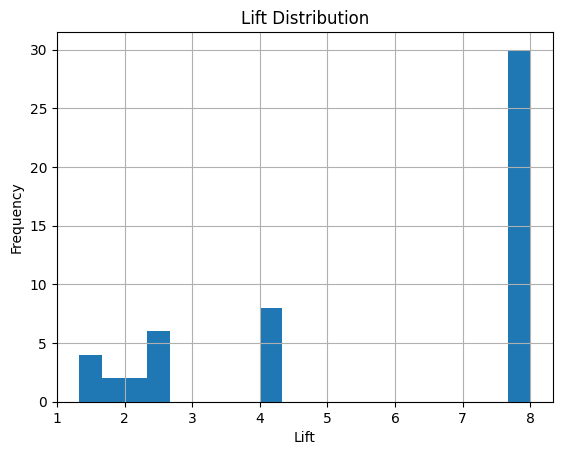

In [11]:
import matplotlib.pyplot as plt

rules["lift"].hist(bins=20)
plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.show()